<a href="https://colab.research.google.com/github/KhushiKeswani/Churn-Prediction-using-ML/blob/main/Product_Image_quality_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
pip install opencv-python

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50

In [ ]:
model = ResNet50(weights='imagenet', include_top=False)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "khushikeswani",\r\n  "key": "KGAT_9a812f10f591afc10226ab183926b81c"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small


Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
 94% 533M/565M [00:03<00:00, 79.3MB/s]
100% 565M/565M [00:03<00:00, 179MB/s] 


In [ ]:
import zipfile
import os

# Replace 'dataset-name.zip' with the actual name of the downloaded zip file
zip_file_name = 'fashion-product-images-small.zip'

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_folder') # Specify a destination folder

# Optional: Remove the zip file after extraction
os.remove(zip_file_name)


In [ ]:
import os
import random
import shutil

SOURCE_DIR = "/content/dataset_folder/images"      # 44k images
TARGET_DIR = "dataset/good_images"
NUM_IMAGES = 10000

os.makedirs(TARGET_DIR, exist_ok=True)

all_images = os.listdir(SOURCE_DIR)
sampled_images = random.sample(all_images, NUM_IMAGES)

for img in sampled_images:
    src = os.path.join(SOURCE_DIR, img)
    dst = os.path.join(TARGET_DIR, img)
    shutil.copy(src, dst)

print("10k images copied successfully")


10k images copied successfully


In [ ]:
import cv2
import numpy as np
import os
import random
from tqdm import tqdm

# Paths
GOOD_DIR = "dataset/good_images"
BAD_DIR = "dataset/bad"

os.makedirs(BAD_DIR, exist_ok=True)

def add_blur(img):
    k = random.choice([3, 5, 7])
    return cv2.GaussianBlur(img, (k, k), 0)

def add_noise(img):
    noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
    return cv2.add(img, noise)

def reduce_quality(img):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), random.randint(10, 40)]
    _, enc = cv2.imencode('.jpg', img, encode_param)
    return cv2.imdecode(enc, 1)

def reduce_resolution(img):
    h, w = img.shape[:2]
    scale = random.choice([0.3, 0.5, 0.7])
    small = cv2.resize(img, (int(w*scale), int(h*scale)))
    return cv2.resize(small, (w, h))

def change_brightness(img):
    value = random.randint(-60, 60)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Convert the V channel to int16 to allow for negative values during addition
    hsv_v_channel = hsv[:, :, 2].astype(np.int16)
    # Perform the addition
    hsv_v_channel = hsv_v_channel + value
    # Clip the result and convert back to uint8
    hsv[:, :, 2] = np.clip(hsv_v_channel, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def make_bad_image(img):
    operations = [
        add_blur,
        add_noise,
        reduce_quality,
        reduce_resolution,
        change_brightness
    ]
    random.shuffle(operations)
    for op in operations[:random.randint(1, 3)]:
        img = op(img)
    return img

good_images = os.listdir(GOOD_DIR)

count = 0
TARGET = 10000

with tqdm(total=TARGET) as pbar:
    while count < TARGET:
        for img_name in good_images:
            if count >= TARGET:
                break

            img_path = os.path.join(GOOD_DIR, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            bad_img = make_bad_image(img)

            save_name = f"bad_{count}.jpg"
            cv2.imwrite(os.path.join(BAD_DIR, save_name), bad_img)

            count += 1
            pbar.update(1)


100%|██████████| 10000/10000 [00:06<00:00, 1484.95it/s]


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "dataset",
    subset="training",
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

val_gen = datagen.flow_from_directory(
    "dataset",
    subset="validation",
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)


Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(
    weights='imagenet',     # transfer learning
    include_top=False,      # remove ImageNet classifier
    input_shape=(256, 256, 3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # binary

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 136ms/step - accuracy: 0.6249 - loss: 0.6560 - val_accuracy: 0.8008 - val_loss: 0.4891
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.7836 - loss: 0.5121 - val_accuracy: 0.8380 - val_loss: 0.4432
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.8101 - loss: 0.4716 - val_accuracy: 0.8478 - val_loss: 0.4248
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.8097 - loss: 0.4620 - val_accuracy: 0.8447 - val_loss: 0.4094
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.8216 - loss: 0.4423 - val_accuracy: 0.8482 - val_loss: 0.4040


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
def predict_output(image_path):
  img_path =image_path  # path to your image

  # Load image with target size same as model input
  img = image.load_img(img_path, target_size=(256, 256))
  plt.imshow(img)
  plt.show()

  # Convert image to array
  img_array = image.img_to_array(img)

  # Add batch dimension (model expects shape [batch, height, width, channels])
  img_array = np.expand_dims(img_array, axis=0)

  # Normalize pixel values if your model was trained with normalized images
  img_array = img_array / 255.0

  pred = model.predict(img_array)[0][0]  # sigmoid output for binary classification

  # Output
  print("Prediction probability:", pred)
  print("Good" if pred > 0.5 else "Bad")


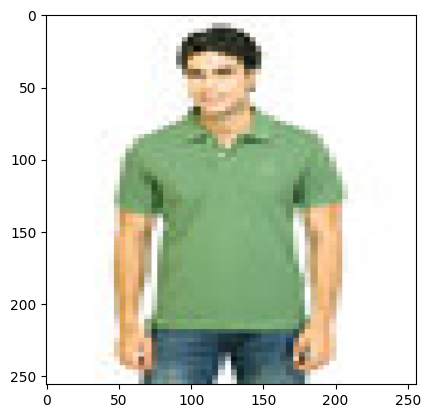

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction probability: 0.69638884
Good


In [ ]:
predict_output("/content/dataset/good_images/15189.jpg")

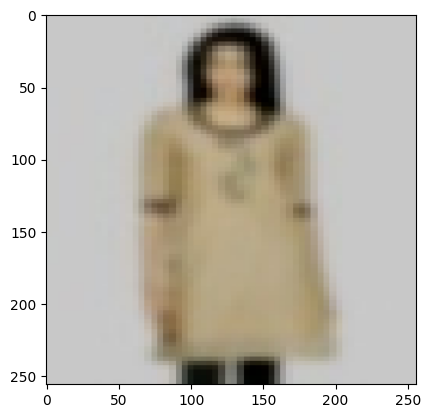

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction probability: 0.25832847
Bad


In [ ]:
predict_output("/content/dataset/bad/bad_106.jpg")

Accurately predicting good and bad images

Some good images have intact strutural details and appear slightly blurred in the output because preprocessing steps like resizing and interpolation inevitably lose fine details. When high-resolution images are scaled down to the model’s input size, pixel information gets compressed, causing a blur-like effect,even though the original image quality is actually good but it still can easily refine bad images

### This model automatically detects low-quality images by analyzing blur, noise, resolution loss, and lighting issues,helping ensure only high-quality visuals are used in production. It can be applied in e-commerce platforms, content-upload systems, or photography pipelines to automatically filter out unusable images. By reducing manual inspection and improving overall visual quality, it enhances user experience, increases trust, and saves significant operational time.